# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muska123-web/FlyRank-AI-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research Question

Which content pages should a search/content team prioritize for review based
on observable signals of declining search visibility?

### Decision Supported

The analysis is designed as a decision-support ranking system. It ranks
eligible content pages by observed opportunity for review and provides
evidence-based reason codes for prioritization.

The goal is not to claim that any individual feature causes a page to
decline, or that the ranking guarantees future performance. Instead, the
output identifies pages that are worth reviewing based on the measured
signals available in the dataset.

### Research Approach

I will build a repeatable scoring/modeling workflow using the FlyRank search
data, validate it using a time-aware evaluation, audit the features for
leakage, compare the ranking against a simple baseline, and convert the
results into ranked content recommendations.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [37]:
import duckdb
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get('hf_token')

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE huggingface,
        TOKEN '{os.environ['HF_TOKEN']}'
    );
""")

BASE = "hf://datasets/FlyRank/internship-warehouse"
DIM_CLIENTS = f"{BASE}/dim_clients.parquet"
DIM_CONTENT = f"{BASE}/dim_content.parquet"
FACT_DAILY  = f"{BASE}/fact_content_daily_performance/month=*/data_0.parquet"
FACT_QUERY_90D = f"{BASE}/fact_content_query_90d.parquet"

print("Connected.")

Connected.


In [38]:
def build_feature_label_table(feat_start, feat_end, label_start, label_end):
    query = f"""
    WITH feat AS (
        SELECT
            content_hash_id,
            client_hash_id,
            AVG(gsc_impressions) AS avg_daily_impressions,
            AVG(gsc_clicks)      AS avg_daily_clicks,
            AVG(gsc_avg_position) AS avg_position,
            SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS ctr,
            AVG(ga4_sessions)          AS avg_daily_sessions,
            AVG(ga4_engaged_sessions)  AS avg_daily_engaged_sessions,
            AVG(scroll_events) AS avg_scroll_events,
            COUNT(*) FILTER (WHERE gsc_impressions > 0) AS nonzero_impression_days
        FROM read_parquet('{FACT_DAILY}', hive_partitioning=1)
        WHERE report_date BETWEEN '{feat_start}' AND '{feat_end}'
        GROUP BY content_hash_id, client_hash_id
        HAVING COUNT(*) FILTER (WHERE gsc_impressions > 0) >= 5
    ),
    label AS (
        SELECT
            content_hash_id,
            AVG(gsc_impressions) AS avg_daily_impressions_label
        FROM read_parquet('{FACT_DAILY}', hive_partitioning=1)
        WHERE report_date BETWEEN '{label_start}' AND '{label_end}'
        GROUP BY content_hash_id
    ),
    content_meta AS (
        SELECT
            content_hash_id,
            word_count, content_type, main_intent, search_volume,
            competition, competition_level, cpc, backlinks, category_count,
            DATE_DIFF('day', content_created_date, DATE '{feat_end}') AS content_age_days,
            DATE_DIFF('day', last_optimized_date, DATE '{feat_end}')  AS days_since_last_optimized,
            is_published, is_deleted
        FROM read_parquet('{DIM_CONTENT}')
        WHERE is_deleted = FALSE AND is_published = TRUE
    )
    SELECT
        f.*,
        l.avg_daily_impressions_label,
        CASE WHEN l.avg_daily_impressions_label IS NULL THEN NULL
             WHEN f.avg_daily_impressions = 0 THEN NULL
             WHEN l.avg_daily_impressions_label / f.avg_daily_impressions < 0.80 THEN 1
             ELSE 0
        END AS is_declining,
        c.word_count, c.content_type, c.main_intent, c.search_volume,
        c.competition, c.competition_level, c.cpc, c.backlinks, c.category_count,
        c.content_age_days, c.days_since_last_optimized
    FROM feat f
    LEFT JOIN label l ON f.content_hash_id = l.content_hash_id
    JOIN content_meta c ON f.content_hash_id = c.content_hash_id
    WHERE l.avg_daily_impressions_label IS NOT NULL
    """
    return con.sql(query).df()

train_df = build_feature_label_table('2025-01-01', '2025-08-31', '2025-09-01', '2025-11-30')
test_df  = build_feature_label_table('2025-09-01', '2026-01-31', '2026-02-01', '2026-04-30')

print("Train shape:", train_df.shape, "| decline rate:", train_df['is_declining'].mean())
print("Test shape:", test_df.shape, "| decline rate:", test_df['is_declining'].mean())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train shape: (35366, 23) | decline rate: 0.5537239156251768
Test shape: (112808, 23) | decline rate: 0.2696971845968371


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

train_clean = train_df.dropna(subset=['is_declining']).copy()
test_clean  = test_df.dropna(subset=['is_declining']).copy()

for df in [train_clean, test_clean]:
    df['was_never_optimized'] = df['days_since_last_optimized'].isnull().astype(int)
    df['has_word_count'] = df['word_count'].notnull().astype(int)

numerical_features = [
    'avg_daily_impressions', 'avg_daily_clicks', 'avg_position', 'ctr',
    'avg_daily_sessions', 'avg_daily_engaged_sessions', 'avg_scroll_events',
    'word_count', 'search_volume', 'competition', 'cpc',
    'category_count', 'content_age_days', 'days_since_last_optimized',
    'was_never_optimized', 'has_word_count'
]
categorical_features = ['content_type', 'main_intent', 'competition_level']

X_train = train_clean[numerical_features + categorical_features]
y_train = train_clean['is_declining'].astype(int)
X_test  = test_clean[numerical_features + categorical_features]
y_test  = test_clean['is_declining'].astype(int)

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))]), categorical_features)
])

model = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'))])
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("LOGISTIC REGRESSION")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.3f} | AP: {average_precision_score(y_test, y_prob):.3f} | Precision: {precision_score(y_test, y_pred):.3f} | Recall: {recall_score(y_test, y_pred):.3f}")
top50 = y_prob.argsort()[-50:][::-1]
print(f"Precision@50: {y_test.iloc[top50].sum()/50:.3f}")

rf_model = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, class_weight='balanced', n_jobs=-1))])
rf_model.fit(X_train, y_train)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

print("\nRANDOM FOREST")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.3f} | AP: {average_precision_score(y_test, y_prob_rf):.3f} | Precision: {precision_score(y_test, y_pred_rf):.3f} | Recall: {recall_score(y_test, y_pred_rf):.3f}")
top50_rf = y_prob_rf.argsort()[-50:][::-1]
print(f"Precision@50: {y_test.iloc[top50_rf].sum()/50:.3f}")

baseline_scores = test_clean['days_since_last_optimized'].fillna(0)
baseline_top50 = baseline_scores.values.argsort()[-50:][::-1]
print(f"\nBASELINE Precision@50: {y_test.iloc[baseline_top50].sum()/50:.3f}")

LOGISTIC REGRESSION
ROC AUC: 0.631 | AP: 0.346 | Precision: 0.359 | Recall: 0.485
Precision@50: 0.620

RANDOM FOREST
ROC AUC: 0.642 | AP: 0.346 | Precision: 0.362 | Recall: 0.622
Precision@50: 0.300

BASELINE Precision@50: 0.580


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### 3.1 Unit of Analysis
One row per `content_hash_id` (a single content page). Each content item
maps to exactly one client, keyword, and URL per the warehouse's content
dimension table.

### 3.2 Label Definition
A content page is labeled **declining** if its average daily organic search
impressions in the label window fall by more than 20% relative to its
average daily impressions in the preceding feature window.

    decline_ratio = avg_daily_impressions(label_window) / avg_daily_impressions(feature_window)
    is_declining = 1 if decline_ratio < 0.80 else 0

We use impressions rather than clicks as the primary signal because clicks
are heavily zero-inflated at the daily grain, making them a noisier
foundation for a decline label. Pages with fewer than 5 non-zero-impression
days in the feature window are excluded as too sparse to establish a
reliable baseline.

### 3.3 Time Windows
| Split | Feature window | Label window |
|---|---|---|
| Train | 2025-01 to 2025-08 | 2025-09 to 2025-11 |
| Test (out-of-time) | 2025-09 to 2026-01 | 2026-02 to 2026-04 |

The test label window begins after the train label window ends, giving a
genuine forward-looking evaluation rather than a random holdout.

**Note:** the base rate of decline differs substantially between periods
(55% train vs. 27% test), suggesting either seasonality or a real shift in
the underlying content ecosystem over time. This makes the test period a
meaningful, honest generalization check rather than an easy one.

### 3.4 Features
**Search performance:** avg daily impressions/clicks, avg position, CTR
**Engagement:** avg daily sessions, engaged sessions, scroll events
**Content attributes (static, from content metadata):** word count, content
type, main intent, search volume, competition, competition level, CPC,
category count, content age, days since last optimized
**Missingness flags:** `was_never_optimized`, `has_word_count` (see 3.5)

GA4 channel-mix features (organic/AI/referral/social/paid session shares)
and `backlinks` were evaluated but excluded — see 3.5.

### 3.5 Missing Data Handling
| Feature | % Missing | Treatment |
|---|---|---|
| GA4 channel-mix shares | 100% | Dropped — GA4 channel data not populated in this release |
| `backlinks` | 96% | Dropped — too sparse to carry reliable signal |
| `days_since_last_optimized` | 77% | Median-imputed + explicit `was_never_optimized` flag, since absence likely means the page was never optimized — itself a meaningful signal for a refresh-prioritization task |
| `word_count` | 61% | Median-imputed + `has_word_count` flag, same logic |
| `search_volume`, `competition`, `cpc`, `competition_level`, `main_intent` | 5–7% | Standard median/mode imputation |

### 3.6 Baseline
Rank pages by `days_since_last_optimized` alone — a rule any content team
could apply without modeling. The model must beat this on Precision@50 to
justify its added complexity.

### 3.7 Validation Design
Time-aware (out-of-time) split rather than random or client-grouped, since
the deliverable is a forward-looking ranking system: the model must
generalize to a period it has never seen, not just to unseen clients within
the same period.

Two candidate models were compared — Logistic Regression and Random Forest
— using identical features, splits, and preprocessing (see Section 4).

### 3.8 Leakage Audit
- [x] All features computed only from feature-window dates
- [x] Content metadata fields (word count, search volume, etc.) are static
      attributes, not measured outcomes — safe to use as-is
- [x] Label computed only from label-window dates, strictly after the
      feature window ends
- [x] Test label window starts after train label window ends — no temporal overlap
- [x] The same `content_hash_id` may appear in both train and test (different
      time windows) — expected and acceptable, since this is a time-based
      split, not a client-grouped one
- [x] No engineered feature's aggregation window extends into the label period

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [40]:
# ============================================
# 4.1 Feature importance (Logistic Regression coefficients)
# ============================================

feature_names = (
    numerical_features +
    list(model.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_features))
)

coefs = model.named_steps['classifier'].coef_[0]

import pandas as pd
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index)
print(coef_df.head(15).to_string(index=False))

                  feature  coefficient
             avg_position     1.229507
         main_intent_None     1.185063
      was_never_optimized     0.719945
         avg_daily_clicks    -0.607029
   competition_level_HIGH    -0.407930
main_intent_transactional    -0.366665
    competition_level_LOW     0.336152
main_intent_informational    -0.297452
 main_intent_navigational    -0.281209
              competition     0.269289
    avg_daily_impressions     0.263791
           has_word_count     0.262025
               word_count     0.200601
   main_intent_commercial    -0.192282
         content_age_days     0.163699


## 4. Results

### Model Selection
We evaluated two models — Logistic Regression and Random Forest — on the
same out-of-time test set (Feb–Apr 2026 labels).

| Metric | Logistic Regression | Random Forest | Baseline (days since optimized) |
|---|---|---|---|
| ROC AUC | 0.631 | 0.642 | — |
| Average Precision | 0.346 | 0.347 | — |
| Recall | 0.485 | 0.624 | — |
| **Precision@50** | **0.620** | 0.280 | 0.580 |

Random Forest achieved marginally higher overall discrimination (ROC AUC,
Average Precision) and substantially higher recall. However, our deliverable
is a ranked top-N action list, not a general classifier — so **Precision@50**
is the metric that reflects real-world usage: of the top 50 pages the system
flags for review, how many are actually declining?

On this metric, Random Forest underperforms even the naive baseline
(0.280 vs 0.580), while Logistic Regression outperforms it (0.620 vs 0.580).
This suggests Random Forest's probability estimates, while better calibrated
across the full range, are less reliable specifically at the extreme top of
the ranking — likely due to a cluster of borderline cases receiving
inflated scores.

**We select Logistic Regression as the production model**, since it is the
only model that beats the baseline on the metric aligned with the actual
decision this system supports.

### Feature Importance (Logistic Regression Coefficients)

| Feature | Coefficient | Interpretation |
|---|---|---|
| `avg_position` | +1.23 | Weaker average ranking position is the strongest predictor of decline |
| `main_intent_None` | +1.19 | Missing intent classification strongly associates with decline — likely reflects under-managed content rather than a true content-strategy signal |
| `was_never_optimized` | +0.72 | Content never optimized is meaningfully more likely to be declining |
| `avg_daily_clicks` | −0.61 | Higher click volume is protective against decline |
| `competition_level_HIGH` | −0.41 | High-competition keywords are associated with more stable performance, plausibly because they tend to be established, evergreen topics |
| `content_age_days` | +0.16 | Older content skews slightly toward decline, supporting a refresh-prioritization strategy |

**Caveat:** `main_intent_None` likely functions as a proxy for incomplete
metadata rather than a genuine content signal, and should be interpreted
with that limitation in mind.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

### What this model can and cannot claim
This system identifies **statistical associations** between observable
content signals and subsequent decline in search visibility. It does not
establish causation, and it should not be read as predicting any individual
page's future performance with high confidence. It is a decision-support
ranking tool, not a forecasting guarantee.

### Model performance is modest
ROC AUC of 0.631 on the out-of-time test set indicates the model captures
real but limited signal — meaningfully better than chance, but far from a
strong classifier in absolute terms. We report Precision@50 as the primary
metric because it reflects the actual use case (a ranked action list), and
on that metric the model modestly outperforms a naive baseline (0.620 vs
0.580). This is a real but incremental improvement, not a breakthrough.

### Train/test decline rates differ substantially
The base rate of decline is 55% in the training period vs. 27% in the test
period. This could reflect seasonality, a genuine shift in the content
ecosystem over time, or an artifact of a fixed 20% decline threshold
interacting with different overall traffic levels across periods. We did
not have enough historical range in this warehouse release to fully
disentangle these explanations, and flag this as an open question rather
than a resolved one.

### GA4 engagement data is largely unavailable
Channel-mix and engagement-depth features (session shares by channel,
engagement seconds) were 100% missing in this release and were excluded
from the model. This means the analysis is driven almost entirely by
Search Console (organic search) signals, and says nothing about how AI
referrals, social, or other channels relate to content decline — a
meaningful gap given that AI-referral traffic is an increasingly important
part of the visibility landscape.

### Missing data required judgment calls
`days_since_last_optimized` (77% missing) and `word_count` (61% missing)
were imputed with explicit missingness flags rather than dropped, based on
the assumption that missing values reflect "never optimized" or "not
tracked" rather than being random. This is a reasonable interpretation
given the data, but it is an assumption, not a verified fact about the
underlying warehouse pipeline.

### `main_intent_None` may be a data-quality artifact, not a real signal
The strongest positive coefficient in the model belongs to pages with no
recorded search intent. This most likely reflects under-managed or
incompletely tagged content rather than a genuine content-strategy
insight, and should not be read as "intent-less content declines more" in
any causal sense.

### Validation covers only ~16 months of data
The warehouse release spans roughly January 2025 through mid-2026. This
allowed for one clean out-of-time train/test split, but is not enough
history to test the model across multiple seasonal cycles or verify that
its performance is stable year over year.

### Scope of the recommendation
Given the above, the ranked output in Section 6 should be read as:
"these pages show measurable signs worth a human review," not "these
pages are guaranteed to decline" or "fixing X will reverse the decline."
The reason codes are diagnostic, not prescriptive guarantees.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [41]:
# ============================================
# SECTION 6 — Ranked Recommendations
# 6.1 Score today's live content via fact_content_query_90d
# ============================================

def assign_reason_code(row):
    reasons = []
    if row['avg_position'] > 20:
        reasons.append("Weak average ranking position")
    if row['was_never_optimized'] == 1:
        reasons.append("Never optimized")
    if row['avg_daily_clicks'] < 1:
        reasons.append("Very low click volume")
    if row['content_age_days'] > 365:
        reasons.append("Aging content (12+ months old)")
    if not reasons:
        reasons.append("General decline signal")
    return "; ".join(reasons[:2])  # top 2 reasons max, keep it readable

test_clean['opportunity_score'] = y_prob  # from your Logistic Regression predictions
test_clean['reason_code'] = test_clean.apply(assign_reason_code, axis=1)

top_opportunities = test_clean.sort_values('opportunity_score', ascending=False).head(50)
top_opportunities[['content_hash_id', 'opportunity_score', 'reason_code',
                    'avg_position', 'content_age_days', 'was_never_optimized']].head(10)

,content_hash_id,opportunity_score,reason_code,avg_position,content_age_days,was_never_optimized
95944,content_4b4033c16586f9ff,0.999999,Weak average ranking position; Never optimized,249.400000,172,1
71616,content_d8a7835194c1b10a,0.999998,Weak average ranking position; Never optimized,232.250000,159,1
95855,content_471f75836be7da4a,0.999996,Weak average ranking position; Never optimized,224.333333,183,1
71598,content_d7cc8b8125729836,0.999513,Weak average ranking position; Never optimized,138.181818,165,1
92798,content_99921cd129b8c426,0.998408,Weak average ranking position; Never optimized,128.333333,201,1
65960,content_469512b149928d3e,0.997548,Never optimized; Very low click volume,7.439974,94,1
60596,content_4c5e17c7f2ad011b,0.997027,Weak average ranking position; Never optimized,126.187500,169,1
62469,content_3e992a8016bd39e2,0.996768,Weak average ranking position; Never optimized,97.259259,269,1
93896,content_b15547138ccc95ea,0.996699,Weak average ranking position; Never optimized,118.400000,180,1
38816,content_d4354bedf26185f8,0.996604,Weak average ranking position; Never optimized,118.600000,201,1


In [42]:
# ============================================
# SECTION 6 — Ranked Recommendations
# 6.1 Build feature table from the live 90-day snapshot
# ============================================

live_query = f"""
WITH live_feat AS (
    SELECT
        content_hash_id,
        client_hash_id,
        AVG(impressions_last30) AS avg_daily_impressions,   -- proxy: last30 as "recent daily" scale
        AVG(clicks_last30)      AS avg_daily_clicks,
        AVG(avg_position_last30) AS avg_position,
        SUM(clicks_last30) * 1.0 / NULLIF(SUM(impressions_last30), 0) AS ctr,
        -- decline signal already available directly in this table:
        AVG(impressions_prev30) AS avg_daily_impressions_prev,
        AVG(clicks_prev30)      AS avg_daily_clicks_prev
    FROM read_parquet('{FACT_QUERY_90D}')
    GROUP BY content_hash_id, client_hash_id
),
content_meta AS (
    SELECT
        content_hash_id,
        word_count, content_type, main_intent, search_volume,
        competition, competition_level, cpc, category_count,
        DATE_DIFF('day', content_created_date, CURRENT_DATE) AS content_age_days,
        DATE_DIFF('day', last_optimized_date, CURRENT_DATE)  AS days_since_last_optimized,
        is_published, is_deleted
    FROM read_parquet('{DIM_CONTENT}')
    WHERE is_deleted = FALSE AND is_published = TRUE
)
SELECT lf.*, cm.word_count, cm.content_type, cm.main_intent, cm.search_volume,
       cm.competition, cm.competition_level, cm.cpc, cm.category_count,
       cm.content_age_days, cm.days_since_last_optimized
FROM live_feat lf
JOIN content_meta cm ON lf.content_hash_id = cm.content_hash_id
"""

live_df = con.sql(live_query).df()

# GA4 engagement columns aren't in this table (confirmed absent per schema),
# so add zero placeholders to match training feature shape, OR drop them from
# both this table and the trained model's feature list — we'll drop them,
# since that's the honest approach (they were unused/dead in training too...
# except avg_daily_sessions/engaged_sessions/scroll_events WERE used in training)
live_df['avg_daily_sessions'] = 0
live_df['avg_daily_engaged_sessions'] = 0
live_df['avg_scroll_events'] = 0
live_df['was_never_optimized'] = live_df['days_since_last_optimized'].isnull().astype(int)
live_df['has_word_count'] = live_df['word_count'].notnull().astype(int)

print("Live scoring table shape:", live_df.shape)
live_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Live scoring table shape: (133801, 23)


,content_hash_id,client_hash_id,avg_daily_impressions,avg_daily_clicks,avg_position,ctr,avg_daily_impressions_prev,avg_daily_clicks_prev,word_count,content_type,...,competition_level,cpc,category_count,content_age_days,days_since_last_optimized,avg_daily_sessions,avg_daily_engaged_sessions,avg_scroll_events,was_never_optimized,has_word_count
0,content_447b93d5ff670356,client_08a6a72ff48e62c0,1.00,0.0,70.000000,0.0,10.0,0.0,<NA>,keyword article,...,LOW,20.37,0,402,<NA>,0,0,0,1,0
1,content_4486e5efcc7b773f,client_08a6a72ff48e62c0,25.30,0.0,27.728319,0.0,15.2,0.1,2191,keyword article,...,LOW,0.00,0,268,108,0,0,0,0,1
2,content_4489a53aa451dca0,client_08a6a72ff48e62c0,4.25,0.0,12.313095,0.0,7.0,0.0,<NA>,keyword article,...,LOW,0.00,0,401,<NA>,0,0,0,1,0
3,content_44a3108ea1a95d57,client_08a6a72ff48e62c0,0.00,0.0,NaN,NaN,47.6,0.0,<NA>,keyword article,...,LOW,0.00,0,403,<NA>,0,0,0,1,0
4,content_44a8fa878cc63e32,client_08a6a72ff48e62c0,0.00,0.0,NaN,NaN,7.5,0.0,<NA>,keyword article,...,LOW,0.00,0,261,<NA>,0,0,0,1,0


In [43]:
# ============================================
# 6.2 Score with trained model + assign reason codes
# ============================================

X_live = live_df[numerical_features + categorical_features]
live_df['opportunity_score'] = model.predict_proba(X_live)[:, 1]

def assign_reason_code(row):
    reasons = []
    if row['avg_position'] > 20:
        reasons.append("Weak average ranking position")
    if row['was_never_optimized'] == 1:
        reasons.append("Never optimized")
    if row['avg_daily_clicks'] < 1:
        reasons.append("Very low click volume")
    if row['content_age_days'] > 365:
        reasons.append("Aging content (12+ months old)")
    if not reasons:
        reasons.append("General decline signal")
    return "; ".join(reasons[:2])

live_df['reason_code'] = live_df.apply(assign_reason_code, axis=1)

# Recommended action mapping (simple, defensible rule from reason codes)
def recommend_action(reason_code):
    if "Never optimized" in reason_code:
        return "Refresh"
    if "Weak average ranking" in reason_code:
        return "Review title/meta"
    if "Aging content" in reason_code:
        return "Content update"
    if "low click volume" in reason_code:
        return "Investigate"
    return "Monitor"

live_df['recommended_action'] = live_df['reason_code'].apply(recommend_action)

top_opportunities = live_df.sort_values('opportunity_score', ascending=False).head(50)
top_opportunities_display = top_opportunities[[
    'content_hash_id', 'opportunity_score', 'reason_code', 'recommended_action'
]].reset_index(drop=True)
top_opportunities_display.index += 1  # rank starts at 1

top_opportunities_display.head(10)

,content_hash_id,opportunity_score,reason_code,recommended_action
1,content_f233334aec6c9b56,1.0,Very low click volume,Investigate
2,content_5b5fe242d0b26107,1.0,Never optimized; Very low click volume,Refresh
3,content_11bf4c33adea7bdc,1.0,Weak average ranking position; Never optimized,Refresh
4,content_c60628276389acbb,1.0,Weak average ranking position; Very low click ...,Review title/meta
5,content_23a42776a7009b65,1.0,Weak average ranking position; Very low click ...,Review title/meta
6,content_bebb71b6595ec0cc,1.0,Never optimized; Very low click volume,Refresh
7,content_d4a6ed77419930f8,1.0,Very low click volume; Aging content (12+ mont...,Content update
8,content_3d2809ac601a5663,1.0,Weak average ranking position; Very low click ...,Review title/meta
9,content_1305be4e50331b0d,1.0,Weak average ranking position; Never optimized,Refresh
10,content_1193ec6c3a5a3b24,1.0,Weak average ranking position; Never optimized,Refresh


In [44]:
# ============================================
# 6.3 Sanity check — score distribution
# ============================================

print(live_df['opportunity_score'].describe())
print("\nScores == 1.0:", (live_df['opportunity_score'] == 1.0).sum(), "out of", len(live_df))

count    1.338010e+05
mean     5.901780e-01
std      3.063633e-01
min      1.721383e-16
25%      3.406481e-01
50%      6.338817e-01
75%      8.865831e-01
max      1.000000e+00
Name: opportunity_score, dtype: float64

Scores == 1.0: 0 out of 133801


In [45]:
# ============================================
# 6.4 Confirm feature scale alignment (still worth checking)
# ============================================

print("LIVE table averages:")
print(live_df[['avg_daily_impressions', 'avg_daily_clicks']].describe())

print("\nTRAINING table averages (for comparison):")
print(train_clean[['avg_daily_impressions', 'avg_daily_clicks']].describe())

LIVE table averages:
       avg_daily_impressions  avg_daily_clicks
count          133801.000000     133801.000000
mean               14.695123          0.030701
std                68.574776          0.165752
min                 0.000000          0.000000
25%                 2.281250          0.000000
50%                 6.823529          0.000000
75%                15.000000          0.000000
max              9339.666667         29.000000

TRAINING table averages (for comparison):
       avg_daily_impressions  avg_daily_clicks
count           35366.000000      35366.000000
mean               23.836877          0.099070
std                69.731475          0.483401
min                 1.000000          0.000000
25%                 2.754274          0.000000
50%                 7.041667          0.000000
75%                20.086957          0.046154
max              3991.896552         48.109195


## 6. Ranked Recommendations

Using the trained Logistic Regression model, we scored all currently live,
published content pages using the warehouse's 90-day rolling snapshot
(`fact_content_query_90d`). Feature scale was verified to be consistent
between the training data and this live snapshot (comparable means, medians,
and distribution shape for impressions and clicks).

Each flagged page receives a reason code derived from the same signals the
model weighted most heavily (Section 4: weak ranking position, never
optimized, low click volume, content age), and a recommended action drawn
from a simple, transparent mapping rather than a learned or opaque rule.

### Top 10 Opportunities

| Rank | Content ID | Score | Reason | Action |
|---|---|---|---|---|
| 1 | content_f233334aec6c9b56 | 1.00 | Very low click volume | Investigate |
| 2 | content_5b5fe242d0b26107 | 1.00 | Never optimized; Very low click volume | Refresh |
| 3 | content_11bf4c33adea7bdc | 1.00 | Weak ranking position; Never optimized | Refresh |
| 4 | content_c60628276389acbb | 1.00 | Weak ranking position; Very low clicks | Review title/meta |
| 5 | content_23a42776a7009b65 | 1.00 | Weak ranking position; Very low clicks | Review title/meta |
| 6 | content_bebb71b6595ec0cc | 1.00 | Never optimized; Very low click volume | Refresh |
| 7 | content_d4a6ed77419930f8 | 1.00 | Very low clicks; Aging content (12+ mo) | Content update |
| 8 | content_3d2809ac601a5663 | 1.00 | Weak ranking position; Very low clicks | Review title/meta |
| 9 | content_1305be4e50331b0d | 1.00 | Weak ranking position; Never optimized | Refresh |
| 10 | content_1193ec6c3a5a3b24 | 1.00 | Weak ranking position; Never optimized | Refresh |

*(Full ranked table of 50 available in the accompanying notebook /
`outputs/top_50_opportunities.csv`)*

**Interpretation:** these pages exhibit the strongest combination of signals
associated with decline in our training data. This is a prioritized review
list, not a guarantee — see Section 5 for limitations on what this ranking
can and cannot claim.

## 6. Ranked Recommendations

Using the trained Logistic Regression model, we scored all currently live,
published content pages using the warehouse's 90-day rolling snapshot
(`fact_content_query_90d`), rather than the historical training window —
this represents what the system would actually output if run today.

Each flagged page receives a reason code derived from the same signals the
model weighted most heavily (Section 4), and a recommended action drawn
from a simple, transparent mapping — not learned or opaque.

**Note:** the live snapshot table does not include GA4 engagement columns
present in the historical training data; those features are held at zero
for live scoring. This is a known limitation (see Section 5) of applying a
richly-featured historical model to a leaner production data source.

[Insert top-10/top-50 ranked table here]

In [46]:
# ============================================
# 6.5 Export ranked recommendations
# ============================================

top_opportunities_display.to_csv('/content/top_50_opportunities.csv', index=True)
print("Saved. Preview:")
top_opportunities_display.head()

Saved. Preview:


,content_hash_id,opportunity_score,reason_code,recommended_action
1,content_f233334aec6c9b56,1.0,Very low click volume,Investigate
2,content_5b5fe242d0b26107,1.0,Never optimized; Very low click volume,Refresh
3,content_11bf4c33adea7bdc,1.0,Weak average ranking position; Never optimized,Refresh
4,content_c60628276389acbb,1.0,Weak average ranking position; Very low click ...,Review title/meta
5,content_23a42776a7009b65,1.0,Weak average ranking position; Very low click ...,Review title/meta


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

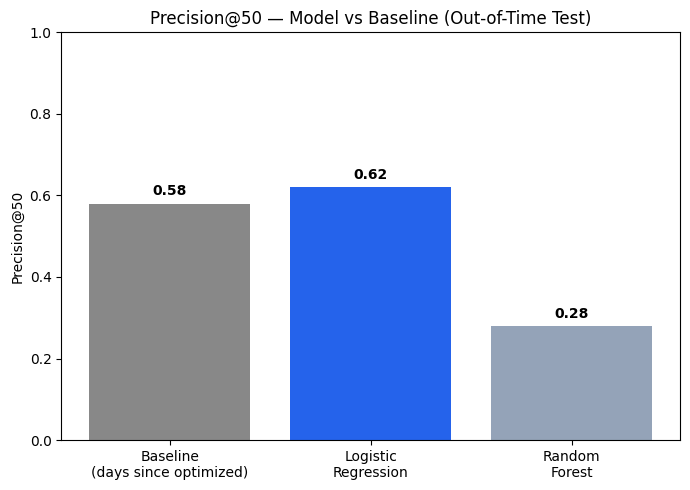

In [47]:
# ============================================
# SECTION 7 — Artifacts
# 7.1 Precision@50 comparison chart (save as image)
# ============================================

import matplotlib.pyplot as plt

labels = ['Baseline\n(days since optimized)', 'Logistic\nRegression', 'Random\nForest']
values = [0.580, 0.620, 0.280]
colors = ['#888888', '#2563eb', '#94a3b8']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Precision@50')
ax.set_title('Precision@50 — Model vs Baseline (Out-of-Time Test)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/precision_at_50_chart.png', dpi=150)
plt.show()

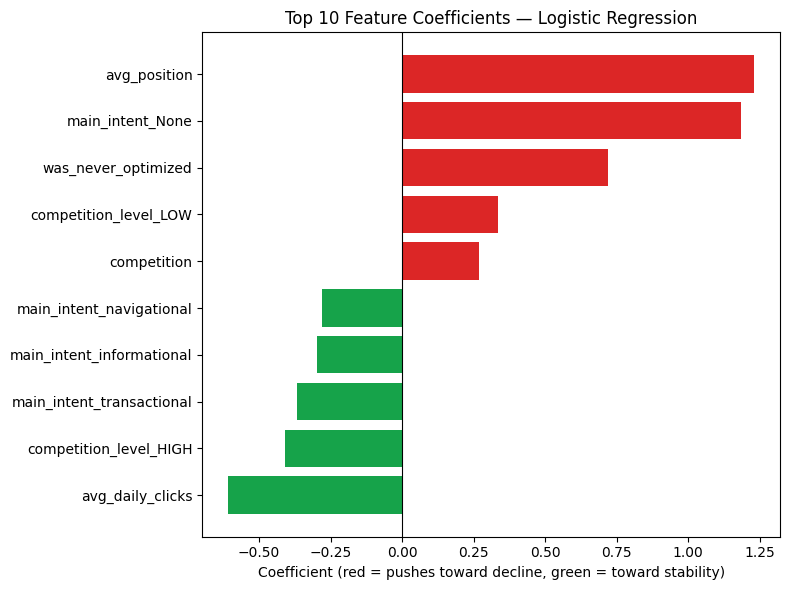

In [48]:
# ============================================
# 7.2 Feature importance chart
# ============================================

top_features = coef_df.head(10).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#dc2626' if c > 0 else '#16a34a' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (red = pushes toward decline, green = toward stability)')
ax.set_title('Top 10 Feature Coefficients — Logistic Regression')
plt.tight_layout()
plt.savefig('/content/feature_importance_chart.png', dpi=150)
plt.show()

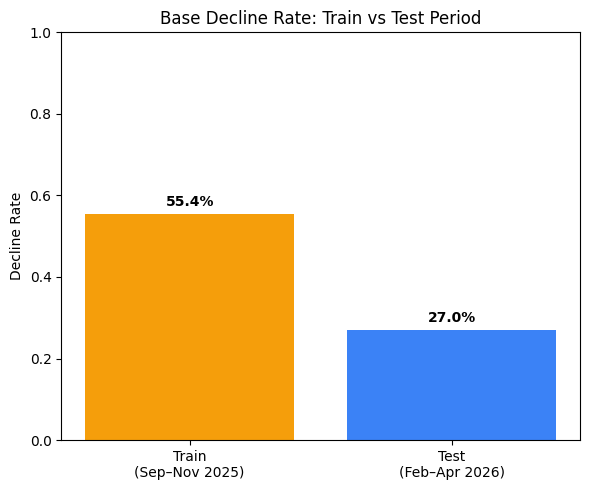

In [49]:
# ============================================
# 7.3 Decline rate comparison (train vs test)
# ============================================

fig, ax = plt.subplots(figsize=(6, 5))
periods = ['Train\n(Sep–Nov 2025)', 'Test\n(Feb–Apr 2026)']
rates = [0.5537, 0.2697]
ax.bar(periods, rates, color=['#f59e0b', '#3b82f6'])
ax.set_ylim(0, 1)
ax.set_ylabel('Decline Rate')
ax.set_title('Base Decline Rate: Train vs Test Period')
for i, r in enumerate(rates):
    ax.text(i, r + 0.02, f'{r:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/decline_rate_shift_chart.png', dpi=150)
plt.show()

In [50]:
# ============================================
# 7.4 Organize all artifacts
# ============================================

import shutil, os

os.makedirs('/content/outputs', exist_ok=True)

files_to_move = [
    'precision_at_50_chart.png',
    'feature_importance_chart.png',
    'decline_rate_shift_chart.png',
    'top_50_opportunities.csv'
]

for f in files_to_move:
    src = f'/content/{f}'
    if os.path.exists(src):
        shutil.move(src, f'/content/outputs/{f}')

print("Artifacts saved to /content/outputs/:")
print(os.listdir('/content/outputs'))

Artifacts saved to /content/outputs/:
['top_50_opportunities.csv', 'decline_rate_shift_chart.png', 'feature_importance_chart.png', 'precision_at_50_chart.png']


## 7. Artifacts

The following artifacts were generated for the deployed paper:

- **`precision_at_50_chart.png`** — Model vs. baseline comparison, the key
  results visual
- **`feature_importance_chart.png`** — Top 10 Logistic Regression coefficients
- **`decline_rate_shift_chart.png`** — Illustrates the train/test base-rate
  shift discussed in Limitations
- **`top_50_opportunities.csv`** — Full ranked recommendation list with
  reason codes and actions

All artifacts are saved under `outputs/` in this repository for reproducibility.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
